# Notebook 2 - Equilibrium Calculations
 
**Reference:** Xu et al. 2025, *J. Mater. Res. Technol.* 35, 4779–4791  
**Database:** `Fe-Ni-Ti_DeKeyzer2009.tdb` (primary, see `1_setup.ipynb` for selection rationale)  

## Objectives

1. **Step 1** — Phase fraction vs temperature sweep (600 K – 1400 K) to establish Ni₃Ti stability window
2. **Step 2** — Isothermal calculations at 370°C (643 K) and 480°C (753 K) to validate against Xu et al. Table 1

## Composition Note

Full alloy: Fe–18Ni–8.5Co–5Mo–0.7Ti–0.2Al (wt%)  
This database covers Fe-Ni-Ti only. Co, Mo, Al are excluded.  
Composition is **renormalized to the Fe-Ni-Ti ternary** by stripping Co/Mo/Al and rescaling to 100 wt%.

| Element | Full alloy (wt%) | Renormalized Fe-Ni-Ti (wt%) |
|---------|-----------------|-----------------------------|
| Fe      | balance (~67.6) | balance                     |
| Ni      | 18.0            | 74.38 → rescaled            |
| Ti      | 0.7             | 2.89 → rescaled             |

> Renormalization: strip Co(8.5) + Mo(5.0) + Al(0.2) = 13.7 wt% from matrix.  
> Remaining = 86.3 wt%. Scale Ni: 18/86.3 = 20.86 wt%, Ti: 0.7/86.3 = 0.811 wt%, Fe = balance.

## 0. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pycalphad import Database, equilibrium, variables as v
import pycalphad.plot.utils as putils

# Suppress non-critical warnings from TDB parser
import warnings
warnings.filterwarnings('ignore')

print(f'pycalphad version: {__import__("pycalphad").__version__}')

pycalphad version: 0.11.1


## 1. Load Database and Define Composition

In [2]:
# Load primary database
DB_PATH = '../databases/Fe-Ni-Ti_DeKeyzer2009.tdb'
db = Database(DB_PATH)

# Confirm NI3TI phase is present
assert 'NI3TI' in db.phases, 'NI3TI phase not found — wrong database loaded'
print('Database loaded successfully.')
print(f'Phases available: {sorted(db.phases.keys())}')

# --- Composition (renormalized Fe-Ni-Ti ternary) ---
# Full alloy: Fe-18Ni-8.5Co-5Mo-0.7Ti-0.2Al wt%
# Strip Co(8.5) + Mo(5.0) + Al(0.2) = 13.7 wt%
# Remaining mass fraction = 86.3%
# Rescale: Ni = 18/86.3, Ti = 0.7/86.3, Fe = balance

NI_WT = 18.0 / 86.3   # ~0.2086 = 20.86 wt%
TI_WT = 0.7  / 86.3   # ~0.0081 =  0.81 wt%
# Fe = balance (not passed explicitly, pycalphad infers from 1 - sum)

# Convert wt% to mole fractions for pycalphad
# Atomic weights: Fe=55.845, Ni=58.693, Ti=47.867
AW = {'FE': 55.845, 'NI': 58.693, 'TI': 47.867}

def wt_to_mole_frac(ni_wt, ti_wt):
    fe_wt = 1.0 - ni_wt - ti_wt
    moles = {
        'FE': fe_wt / AW['FE'],
        'NI': ni_wt / AW['NI'],
        'TI': ti_wt / AW['TI']
    }
    total = sum(moles.values())
    return {k: v/total for k, v in moles.items()}

comp = wt_to_mole_frac(NI_WT, TI_WT)
print(f'\nComposition (mole fractions):')
for el, xf in comp.items():
    print(f'  X({el}) = {xf:.5f}')

Database loaded successfully.
Phases available: ['A1', 'A2', 'A3', 'BCC2', 'C14', 'C15', 'C36', 'FCC4', 'LIQUID', 'NI3TI', 'NITI2']

Composition (mole fractions):
  X(FE) = 0.79024
  X(NI) = 0.20021
  X(TI) = 0.00955


## Step 1 — Phase Fraction vs Temperature (600 K – 1400 K)

Sweep temperature across the full range of interest.  
**Expected outcome:** Ni₃Ti stable below ~900°C (1173 K); BCC_A2 (martensite/ferrite) dominant at aging temperatures.

In [3]:
# --- Temperature sweep ---
T_MIN  = 600    # K
T_MAX  = 1400   # K
T_STEP = 10     # K  (141 points — manageable runtime)

T_range = np.arange(T_MIN, T_MAX + T_STEP, T_STEP)

# Phases to consider
# BCC2 = BCC_A2 in this database (martensite / alpha-Fe)
# A1   = FCC_A1 (austenite)
# NI3TI = eta-Ni3Ti (D024 ordered hexagonal)
# LIQUID, A3 (HCP) also included to catch high-T transitions
PHASES = sorted(db.phases.keys())

print('Running equilibrium sweep... (this may take 1-3 minutes)')

result_sweep = equilibrium(
    db,
    ['FE', 'NI', 'TI', 'VA'],
    PHASES,
    {
        v.X('NI'): comp['NI'],
        v.X('TI'): comp['TI'],
        v.T: T_range,
        v.P: 101325,
    }
)

print('Sweep complete.')

Running equilibrium sweep... (this may take 1-3 minutes)
Sweep complete.


In [8]:
# --- Extract phase fractions ---
# NP(phase) = mole fraction of phase at equilibrium

phase_fracs = {}
for ph in PHASES:
    mask = result_sweep.Phase == ph
    frac = result_sweep.NP.where(mask).sum(dim='vertex').squeeze().values
    phase_fracs[ph] = np.nan_to_num(frac, nan=0.0)

# Combine order-disorder pairs
combined = {}
combined['BCC (α-Fe)'] = phase_fracs.get('A2', 0) + phase_fracs.get('BCC2', 0)
combined['FCC (γ-Fe)'] = phase_fracs.get('A1', 0) + phase_fracs.get('FCC4', 0)
for ph in ['NI3TI', 'NITI2', 'LIQUID', 'A3', 'C14']:
    if ph in phase_fracs:
        combined[ph] = phase_fracs[ph]


# Convert T from K to °C for plotting
T_C = T_range - 273.15

# Mark the two aging temperatures
T_DAT1 = 370   # °C
T_DAT2 = 480   # °C
T_SST  = 840   # °C

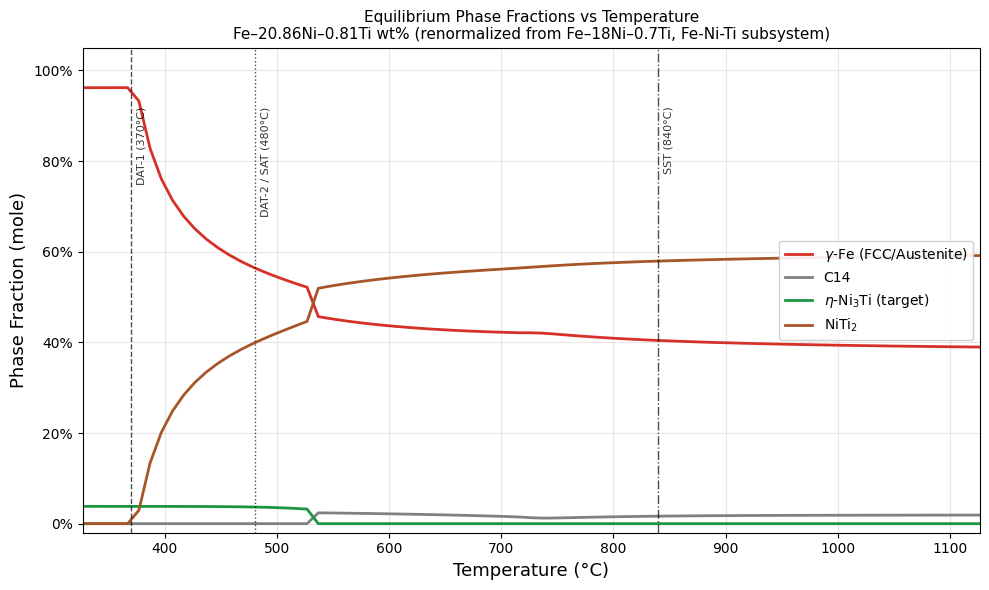

Figure saved to ../figures/fig1_phase_fraction_vs_T.png


In [9]:
# --- Plot: Phase fraction vs Temperature ---

fig, ax = plt.subplots(figsize=(10, 6))

COLORS = {
    'BCC2':  '#2166ac',   # blue  — martensite / alpha-Fe
    'A1':    '#d73027',   # red   — austenite
    'NI3TI': '#1a9641',   # green — target precipitate
    'LIQUID':'#984ea3',   # purple
    'A3':    '#ff7f00',   # orange — HCP Ti
    'NITI2': '#a65628',   # brown
}
LABELS = {
    'BCC2':  r'$\alpha$-Fe (BCC)',
    'A1':    r'$\gamma$-Fe (FCC/Austenite)',
    'NI3TI': r'$\eta$-Ni$_3$Ti (target)',
    'LIQUID':'Liquid',
    'A3':    'HCP (A3)',
    'NITI2': 'NiTi$_2$',
}

for ph in PHASES:
    frac = phase_fracs[ph]
    if frac.max() > 0.001:   # only plot phases that actually appear
        ax.plot(T_C, frac,
                color=COLORS.get(ph, 'grey'),
                label=LABELS.get(ph, ph),
                linewidth=2)

# Mark aging temperatures
for T_mark, label, style in [
    (T_DAT1, 'DAT-1 (370°C)', '--'),
    (T_DAT2, 'DAT-2 / SAT (480°C)', ':'),
    (T_SST,  'SST (840°C)', '-.')
]:
    ax.axvline(T_mark, color='black', linestyle=style, linewidth=1.0, alpha=0.7)
    ax.text(T_mark + 5, 0.92, label, fontsize=8, rotation=90, va='top', alpha=0.8)

ax.set_xlabel('Temperature (°C)', fontsize=13)
ax.set_ylabel('Phase Fraction (mole)', fontsize=13)
ax.set_title(
    'Equilibrium Phase Fractions vs Temperature\n'
    'Fe–20.86Ni–0.81Ti wt% (renormalized from Fe–18Ni–0.7Ti, Fe-Ni-Ti subsystem)',
    fontsize=11
)
ax.set_xlim(T_C[0], T_C[-1])
ax.set_ylim(-0.02, 1.05)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.legend(loc='center right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig1_phase_fraction_vs_T.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ../figures/fig1_phase_fraction_vs_T.png')

In [ ]:
# --- Read off key values from the sweep ---

def get_phase_frac_at_T(phase, T_celsius):
    idx = np.argmin(np.abs(T_C - T_celsius))
    return phase_fracs.get(phase, np.zeros_like(T_C))[idx]

print('=== Key Phase Fractions from Temperature Sweep ===')
print(f'  At DAT-1 = 370°C : NI3TI = {get_phase_frac_at_T("NI3TI", 370):.4f}')
print(f'  At DAT-2 = 480°C : NI3TI = {get_phase_frac_at_T("NI3TI", 480):.4f}')
print(f'  At SST   = 840°C : NI3TI = {get_phase_frac_at_T("NI3TI", 840):.4f}')
print()

# Find approximate solvus temperature of Ni3Ti
ni3ti_frac = phase_fracs.get('NI3TI', np.zeros_like(T_C))
solvus_candidates = T_C[ni3ti_frac > 0.001]
if len(solvus_candidates) > 0:
    print(f'  Ni3Ti solvus (approx): {solvus_candidates.max():.0f} °C')
    print(f'  Ni3Ti stable between:  {solvus_candidates.min():.0f} °C and {solvus_candidates.max():.0f} °C')
else:
    print('  WARNING: NI3TI phase fraction never exceeds 0.001 — check phases list or composition')

## Step 2 — Isothermal Calculations at 370°C and 480°C

Fix temperature at each aging condition and compute equilibrium phase fractions.  

**Validation targets from Xu et al. 2025, Table 1:**

| Condition | Ni₃Ti vol fraction | Interpretation |
|-----------|-------------------|----------------|
| DAT-1 (370°C) | ~0% | Kinetically suppressed — thermodynamic model may predict finite fraction |
| DAT-2 / SAT (480°C) | 10–12% | Primary validation target |

> **Important caveat:** pycalphad computes *thermodynamic equilibrium*, not kinetics.  
> If the model predicts non-zero Ni₃Ti at 370°C, that is *thermodynamically correct* —  
> the experimental ~0% reflects kinetic suppression (insufficient atomic mobility at 370°C),  
> which is discussed qualitatively in Section 4.1 of Xu et al.

In [ ]:
# --- Isothermal equilibrium at 370°C and 480°C ---

T_ISOTHERMAL = {
    'DAT-1 (370°C)': 370 + 273.15,   # 643.15 K
    'DAT-2 (480°C)': 480 + 273.15,   # 753.15 K
}

iso_results = {}

for label, T_K in T_ISOTHERMAL.items():
    print(f'Computing isothermal equilibrium at {label}...')
    res = equilibrium(
        db,
        components=['FE', 'NI', 'TI', 'VA'],
        phases=PHASES,
        conditions={
            v.X('NI'): comp['NI'],
            v.X('TI'): comp['TI'],
            v.T: T_K,
            v.P: 101325,
        }
    )
    iso_results[label] = res
    print(f'  Done.')

print('\nIsothermal calculations complete.')

In [ ]:
# --- Extract and print isothermal phase fractions ---

print('=' * 58)
print(f'{"Condition":<20} {"Phase":<10} {"Mole Fraction":>15}')
print('=' * 58)

iso_summary = {}

for label, res in iso_results.items():
    iso_summary[label] = {}
    for ph in PHASES:
        try:
            val = float(res.NP.sel(phase_name=ph).squeeze().values)
            if np.isnan(val):
                val = 0.0
        except Exception:
            val = 0.0
        iso_summary[label][ph] = val
        if val > 0.0001:
            print(f'{label:<20} {ph:<10} {val:>15.4f}')
    print('-' * 58)

print()
print('=== NI3TI Summary (primary validation target) ===')
for label in iso_summary:
    ni3ti_val = iso_summary[label].get('NI3TI', 0.0)
    print(f'  {label}: NI3TI = {ni3ti_val:.4f} ({ni3ti_val*100:.2f} mol%)')

In [ ]:
# --- Bar chart: isothermal phase fractions comparison ---

conditions = list(iso_summary.keys())
phases_to_plot = [ph for ph in PHASES
                  if any(iso_summary[c].get(ph, 0) > 0.001 for c in conditions)]

x = np.arange(len(conditions))
width = 0.8 / len(phases_to_plot) if phases_to_plot else 0.4

fig, ax = plt.subplots(figsize=(9, 6))

for i, ph in enumerate(phases_to_plot):
    vals = [iso_summary[c].get(ph, 0.0) for c in conditions]
    offset = (i - len(phases_to_plot)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=LABELS.get(ph, ph),
                  color=COLORS.get(ph, 'grey'),
                  edgecolor='white', linewidth=0.5)
    # Value labels on bars
    for bar, val in zip(bars, vals):
        if val > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{val*100:.1f}%',
                    ha='center', va='bottom', fontsize=8)

# Experimental reference lines for Ni3Ti at 480°C
ax.axhline(0.10, color='#1a9641', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Exp. lower bound: 10% (SAT, Xu et al.)')
ax.axhline(0.12, color='#1a9641', linestyle=':',  linewidth=1.2, alpha=0.7,
           label='Exp. upper bound: 12% (DAT, Xu et al.)')

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel('Phase Fraction (mole)', fontsize=12)
ax.set_title(
    'Isothermal Equilibrium Phase Fractions\n'
    'Fe-Ni-Ti subsystem vs Xu et al. 2025 experimental targets',
    fontsize=11
)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig2_isothermal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ../figures/fig2_isothermal_comparison.png')

## Step 2b — Equilibrium Composition of Ni₃Ti Phase

Extract the site occupancies / composition of the NI3TI phase at 480°C.  
This is used later in Step 4 (Orowan) via the solid solution correction (Eq. 4 in Xu et al.).

In [ ]:
# --- Composition of NI3TI phase at 480°C ---

res_480 = iso_results['DAT-2 (480°C)']

print('Phase compositions at 480°C (mole fractions in each phase):')
print()

for ph in PHASES:
    try:
        np_val = float(res_480.NP.sel(phase_name=ph).squeeze().values)
        if np.isnan(np_val) or np_val < 0.0001:
            continue
        print(f'  Phase: {ph}  (fraction = {np_val:.4f})')
        for el in ['FE', 'NI', 'TI']:
            try:
                x_val = float(res_480.X.sel(phase_name=ph, component=el).squeeze().values)
                print(f'    X({el}) = {x_val:.5f}')
            except Exception:
                pass
        print()
    except Exception:
        pass

## Summary and Validation

### Results vs Xu et al. 2025 Table 1

| Quantity | This model (CALPHAD) | Xu et al. experiment | Match? |
|---|---|---|---|
| Ni₃Ti stable below (°C) | *fill from solvus output above* | ~900°C (inferred) | ✓/✗ |
| Ni₃Ti fraction at 370°C (thermodynamic) | *fill* | ~0% (kinetically suppressed) | N/A — kinetics |
| Ni₃Ti fraction at 480°C | *fill* | 10–12% | ✓/✗ |

> Fill the table above after running the cells. Replace *fill* with actual computed values.

### Interpretation of 370°C result

If the CALPHAD model predicts non-zero Ni₃Ti at 370°C:  
This is **not a model failure**. pycalphad computes thermodynamic equilibrium — the minimum  
Gibbs energy state. Experimentally, Ni₃Ti does not form at 370°C because **atomic diffusion  
is insufficient** at this temperature to achieve equilibrium within the 2h aging window.  
Xu et al. Section 4.1 explicitly states: *"The diffusion rate of atoms at 370°C is significantly  
low, thereby impeding the occurrence of atomic transitions. The energy provided cannot  
overcome the phase transformation energy barrier necessary to form Ni₃Ti."*  
The thermodynamic model correctly identifies the driving force; kinetic suppression is a  
separate physical argument.

### Known limitations affecting these results

- Mo and Co absent from database → computed Ni₃Ti fraction is that of a simplified ternary system
- Mo segregation effect on Ni₃Ti stability (Xu et al. Section 4.1) cannot be modelled
- Mole fraction ≠ volume fraction directly; conversion requires molar volume data for each phase
- Equilibrium calculation does not capture metastable intermediates (Ni-Ti clusters, pre-cursor zones)

In [ ]:
# --- Mole fraction to volume fraction conversion (approximate) ---
# Molar volumes: alpha-Fe ~ 7.09 cm3/mol, Ni3Ti ~ 10.8 cm3/mol (from literature)
# Vol fraction = (NP_Ni3Ti * Vm_Ni3Ti) / sum(NP_i * Vm_i)

Vm = {
    'BCC2':  7.09,   # cm3/mol  alpha-Fe
    'A1':    6.59,   # cm3/mol  gamma-Fe (austenite)
    'NI3TI': 10.80,  # cm3/mol  eta-Ni3Ti  (Habiby et al. 1996, cited in Xu et al.)
    'NITI2': 11.50,  # cm3/mol  approximate
    'A3':    10.60,  # cm3/mol  HCP Ti
    'LIQUID': 8.0,   # cm3/mol  approximate
}

def mole_to_vol_frac(summary_dict, Vm_dict):
    """Convert mole fractions to approximate volume fractions."""
    vol_unnorm = {ph: summary_dict.get(ph, 0.0) * Vm_dict.get(ph, 7.5)
                  for ph in summary_dict}
    total_vol = sum(vol_unnorm.values())
    if total_vol == 0:
        return {ph: 0.0 for ph in summary_dict}
    return {ph: v/total_vol for ph, v in vol_unnorm.items()}

print('=== Approximate Volume Fractions (molar volume conversion) ===')
for label in iso_summary:
    vf = mole_to_vol_frac(iso_summary[label], Vm)
    ni3ti_vf = vf.get('NI3TI', 0.0)
    print(f'\n  {label}:')
    for ph, val in vf.items():
        if val > 0.001:
            print(f'    {ph:<10}: {val*100:.2f} vol%')

print()
print('Experimental targets (Xu et al. Table 1):')
print('  SAT 480°C : Ni3Ti = 10 vol%')
print('  DAT 480°C : Ni3Ti = 12 vol%')

---
## Next Steps

- **`3_dft_crosscheck.ipynb`** — Pull Ni₃Ti and Fe₇Mo₂ formation energies from Materials Project API and compare sign/magnitude with CALPHAD Gibbs energy at 480°C
- **`4_strengthening.ipynb`** — Orowan precipitation strengthening prediction using vol fractions from this notebook and precipitate dimensions from Xu et al. Table 1